# Phase 1: 00 — Data Preprocessing, EDA & Pembentukan Data Simulasi
## Analisis Sentimen Bencana Banjir (Dataset Data V2)

**Tujuan Notebook:**
1. Membaca dataset utama `datav2` (`banjir_processed_v2.csv` / `data_banjir.csv`).
2. Melakukan audit dan seluruh tahapan pembersihan teks berbasis regex (*URL, mention, hashtag, noise removal*).
3. Standardisasi kata gaul/slang ke bentuk baku menggunakan kamus leksikon `colloquial-indonesian-lexicon.csv`.
4. Eksplorasi Data (EDA): Visualisasi Word Cloud (keseluruhan korpus dan per kelas sentimen) serta analisis distribusi frekuensi sentimen.
5. Menjalankan *Stratified Train/Validation/Test Split* (72% Train, 8% Val, 20% Test) dengan kunci acak deterministik `random_state=42`.
6. **Membangun 3 Skenario Simulasi Ketimpangan Data Latih**:
   * **Skenario A (1:1:1)**: Seimbang buatan (1.000 Negatif : 1.000 Netral : 1.000 Positif = 3.000 sampel)
   * **Skenario B (6:3:1)**: Ketimpangan moderat (3.000 Negatif : 500 Netral : 1.500 Positif = 5.000 sampel)
   * **Skenario C (8:1:1)**: Ketimpangan ekstrem ekor panjang (3.200 Negatif : 400 Netral : 400 Positif = 4.000 sampel)
7. Menyimpan seluruh partisi (`train.csv`, `validation.csv`, `test.csv`, serta `scenario_111.csv`, `scenario_631.csv`, `scenario_811.csv`) bebas kebocoran data (*Zero Data Leakage*).


### 1. Import Library

In [1]:
import os
import sys
from pathlib import Path

# Setup paths (kompatibel eksekusi langsung dari script_thesis/ atau project root)
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "script_thesis":
    BASE_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    BASE_DIR = PROJECT_ROOT / "script_thesis"

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
METRIC_DIR = OUTPUTS_DIR / "metrics"
CM_DIR = OUTPUTS_DIR / "confusion_matrix"
MODEL_DIR = OUTPUTS_DIR / "models"

for p in [DATA_DIR, FIG_DIR, METRIC_DIR, CM_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Dir    : {DATA_DIR}")
print(f"Outputs Dir : {OUTPUTS_DIR}")

import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150


Project Root: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Data Dir    : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data
Outputs Dir : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs


### 2. Load Dataset Utama (Data V2)

In [2]:
# Pencarian dataset kandidat
candidates = [
    PROJECT_ROOT / "Data" / "processed" / "banjir_processed_v2.csv",
    PROJECT_ROOT / "Data" / "processed" / "data_preprocessed_v2.csv",
    PROJECT_ROOT / "Data" / "raw" / "banjir.csv",
    PROJECT_ROOT / "Data" / "data_banjir.csv",
    PROJECT_ROOT / "kaggle_dataset" / "banjir_processed_v2.csv",
]

data_path = None
for c in candidates:
    if c.exists():
        data_path = c
        break

if data_path is None:
    raise FileNotFoundError("Dataset utama banjir tidak ditemukan di kandidat path.")

print(f"Memuat dataset dari: {data_path}")
df_raw = pd.read_csv(data_path)
print(f"Total baris data: {len(df_raw):,} sampel")
print("Kolom tersedia:", list(df_raw.columns))
df_raw.head(3)


Memuat dataset dari: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\Data\processed\banjir_processed_v2.csv
Total baris data: 8,648 sampel
Kolom tersedia: ['text', 'clean_text', 'created_at', 'keyword', 'processed_text', 'sentimen', 'label', 'emoticon', 'is_truncated', 'clean_text_step1', 'processed_text_v2']


,text,clean_text,created_at,keyword,processed_text,sentimen,label,emoticon,is_truncated,clean_text_step1,processed_text_v2
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu yg m...,2026-01-13,Banjir Sumatra 2025,polisi sulit temu siapa milik kayu sebab banji...,negatif,0,NaN,False,Polisi : Sulit menemukan siapa pemilik kayu yg...,Polisi : Sulit menemukan siapa pemilik kayu ya...
1,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,2026-01-13,Banjir Sumatra 2025,orang ibu panjat tebing bawa bayi puskesmas ga...,negatif,0,NaN,False,Seorang Ibu harus memanjat tebing demi membawa...,Seorang Ibu harus memanjat tebing demi membawa...
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi januari,2026-01-13,Banjir Sumatra 2025,waspada banjir pesisir durasi januari,netral,1,NaN,False,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...


### 3. Konfigurasi Parameter Preprocessing & Split

In [3]:
SEED = 42
TEST_RATIO = 0.20       # 20% Holdout Test Set
VAL_RATIO_OF_TRAIN = 0.10 # 10% dari Train+Val -> 8% total dataset (72% Train, 8% Val, 20% Test)

np.random.seed(SEED)
print(f"Random Seed Terkunci: {SEED}")
print(f"Partisi Rasio: Train 72% | Validation 8% | Test 20%")


Random Seed Terkunci: 42
Partisi Rasio: Train 72% | Validation 8% | Test 20%


### 4. Pipeline Preprocessing Teks
1. **Regex Cleaning**: Menghapus URL, User Mention (`@user`), entitas HTML, angka engagement scraping, dan tanda hashtag (`#`).
2. **Kamus Leksikon Slang**: Standardisasi kata informal menggunakan `kamus/colloquial-indonesian-lexicon.csv`.
3. **Standarisasi Label**: Memetakan sentimen ke integer (`negatif: 0`, `netral: 1`, `positif: 2`).


In [4]:
def clean_tweet_regex(text):
    text = str(text)
    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Hapus user mention
    text = re.sub(r'@\w+', '', text)
    # Hapus hashtag symbol (#banjir -> banjir)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Hapus artefak scraping UI
    text = re.sub(r'\b(tampilkan lebih banyak|membalas|dari tribunnews|baca berita)\b', '', text, flags=re.IGNORECASE)
    # Hapus angka engagement trailing (misal: 2 rb, 35 rb)
    text = re.sub(r'\b\d+\s*(rb|jt)?\b', '', text, flags=re.IGNORECASE)
    # Normalisasi spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load kamus colloquial
kamus_file = PROJECT_ROOT / "kamus" / "colloquial-indonesian-lexicon.csv"
slang_dict = {}
if kamus_file.exists():
    df_kamus = pd.read_csv(kamus_file)
    slang_dict = dict(zip(df_kamus['slang'].astype(str).str.lower(), df_kamus['formal'].astype(str)))
    print(f"Kamus slang dimuat: {len(slang_dict):,} entri")
else:
    print("Warning: Kamus leksikon tidak ditemukan, menggunakan normalisasi regex murni.")

def normalize_slang(text, mapping):
    words = str(text).split()
    return ' '.join([mapping.get(w.lower(), w) for w in words])

text_col = 'text' if 'text' in df_raw.columns else df_raw.columns[0]
label_col = 'label' if 'label' in df_raw.columns else 'sentimen'

df_clean = df_raw.copy()
df_clean['clean_regex'] = df_clean[text_col].apply(clean_tweet_regex)
df_clean['processed_text_v2'] = df_clean['clean_regex'].apply(lambda t: normalize_slang(t, slang_dict))

if df_clean[label_col].dtype == object:
    label_map = {'negatif': 0, 'netral': 1, 'positif': 2, 'negative': 0, 'neutral': 1, 'positive': 2}
    df_clean['label'] = df_clean[label_col].str.lower().map(label_map).fillna(0).astype(int)
else:
    df_clean['label'] = df_clean[label_col].astype(int)

df_clean['text_clean'] = df_clean['processed_text_v2']
print("Contoh Pembersihan Teks:")
print("Mentah :", df_clean[text_col].iloc[0][:120], "...")
print("Bersih :", df_clean['text_clean'].iloc[0][:120], "...")


Kamus slang dimuat: 4,331 entri


Contoh Pembersihan Teks:
Mentah : Polisi : Sulit menemukan siapa pemilik kayu yg menyebabkan banjir Sumatra akhir 2025. Rakyat : Polisi Goblok, Percuma se ...
Bersih : Polisi : Sulit menemukan siapa pemilik kayu yang menyebabkan banjir Sumatra akhir . Rakyat : Polisi Goblok, Percuma seko ...


### 5. Analisis Statistik Distribusi Kelas Sentimen

Statistik Distribusi Sentimen:


,Jumlah Sampel,Persentase (%)
Negatif (0),4686,54.19
Netral (1),1510,17.46
Positif (2),2452,28.35


Tabel statistik tersimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics\distribusi_kelas.csv


C:\Windows\Temp\ipykernel_6468\3050688394.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y=dist_df['Jumlah Sampel'], ax=axes[0], palette=colors)


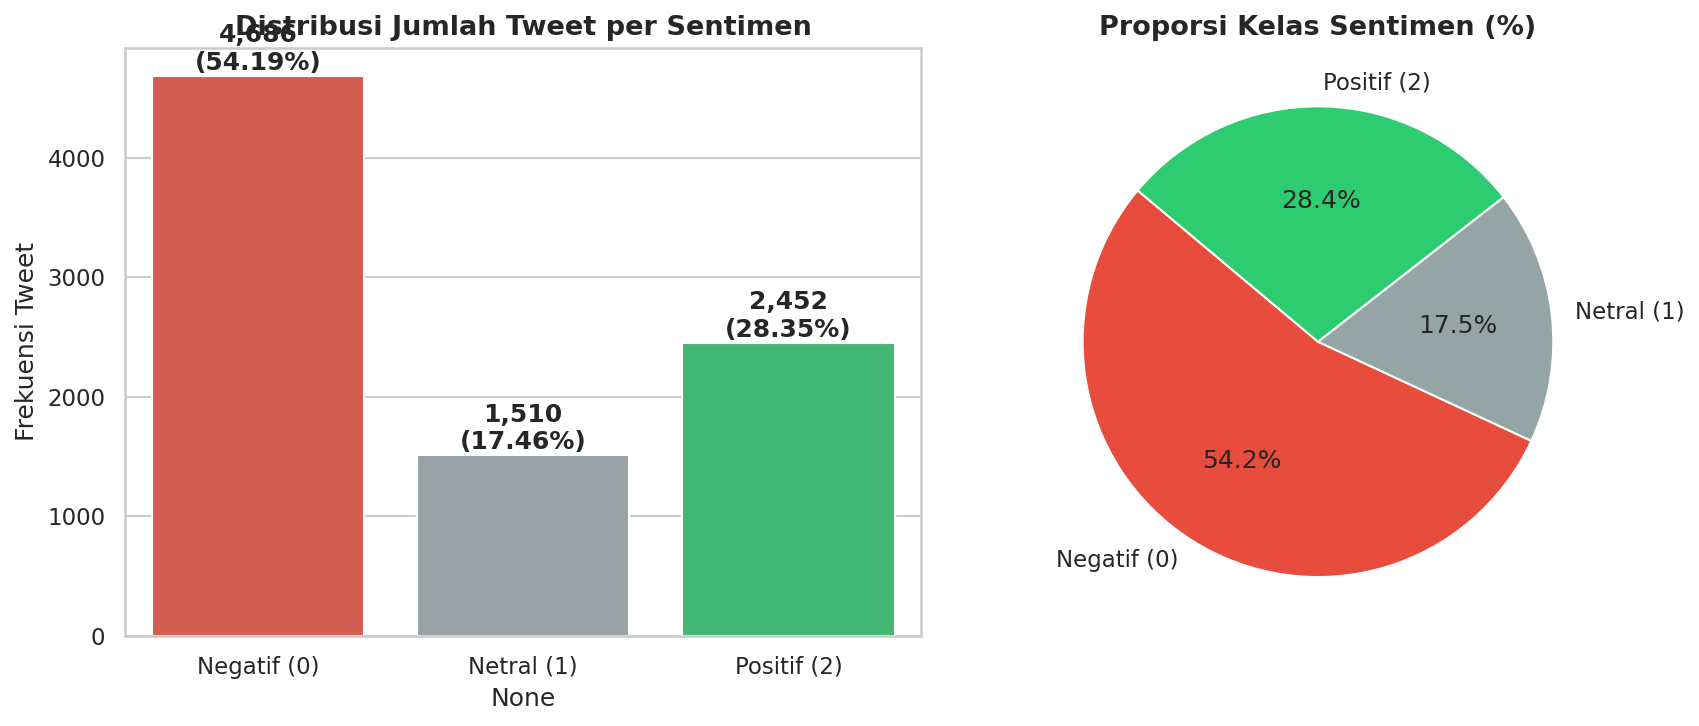

In [5]:
dist_df = pd.DataFrame({
    'Jumlah Sampel': df_clean['label'].value_counts().sort_index(),
    'Persentase (%)': (df_clean['label'].value_counts(normalize=True).sort_index() * 100).round(2)
})
dist_df.index = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print("Statistik Distribusi Sentimen:")
display(dist_df)

dist_df.to_csv(METRIC_DIR / "distribusi_kelas.csv")
print(f"Tabel statistik tersimpan di: {METRIC_DIR / 'distribusi_kelas.csv'}")

# Visualisasi Bar Plot & Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

sns.barplot(x=dist_df.index, y=dist_df['Jumlah Sampel'], ax=axes[0], palette=colors)
axes[0].set_title("Distribusi Jumlah Tweet per Sentimen", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Frekuensi Tweet")
for i, v in enumerate(dist_df['Jumlah Sampel']):
    axes[0].text(i, v + 50, f"{v:,}\n({dist_df['Persentase (%)'].iloc[i]}%)", ha='center', fontweight='bold')

axes[1].pie(dist_df['Jumlah Sampel'], labels=dist_df.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title("Proporsi Kelas Sentimen (%)", fontsize=13, fontweight='bold')

plt.tight_layout()
dist_fig_path = FIG_DIR / "distribusi_kelas.png"
plt.savefig(dist_fig_path, dpi=300, bbox_inches='tight')
plt.show()


### 6. Visualisasi Word Cloud (Keseluruhan & per Kelas)

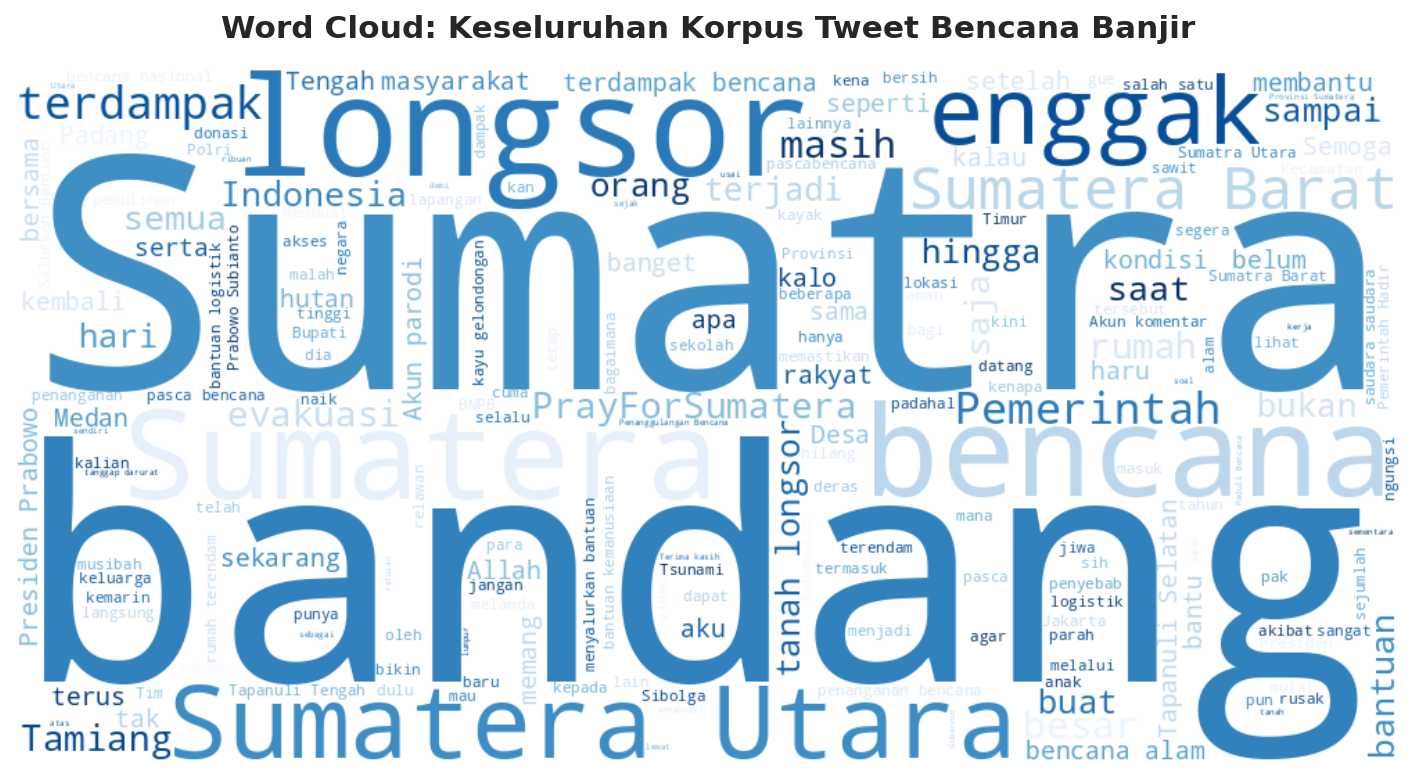

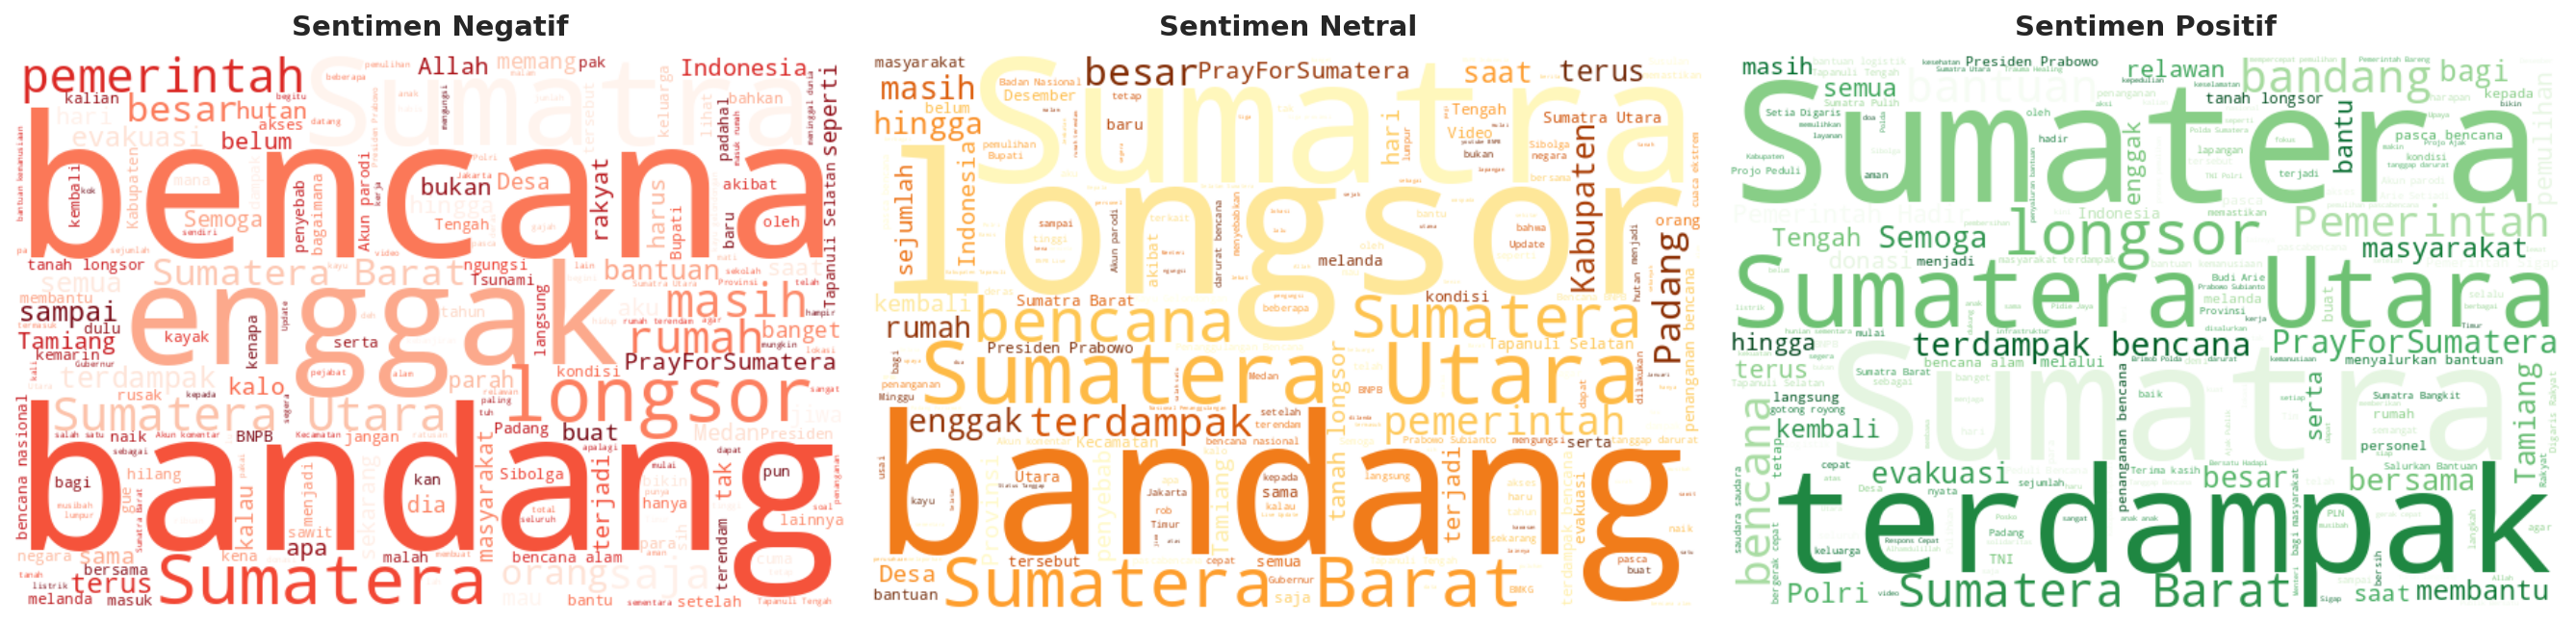

In [6]:
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'yang', 'dan', 'untuk', 'ini', 'itu', 'di', 'ke', 'dari', 'dengan', 'pada', 'adalah',
    'akan', 'sudah', 'ada', 'juga', 'tidak', 'bisa', 'lebih', 'kita', 'saya', 'kami', 'mereka',
    'atau', 'tapi', 'karena', 'jadi', 'lagi', 'banyak', 'dalam', 'ya', 'ga', 'yg', 'nya',
    'sumut', 'sumbar', 'sumsel', 'riau', 'jambi', 'lampung', 'banjir', 'warga', 'korban',
    'air', 'hujan', 'wilayah', 'daerah', 'aceh', 'kota', 'sungai', 'jalan'
])

# 1. WordCloud Keseluruhan Data
text_all = " ".join(df_clean['text_clean'].dropna().tolist())
wc_all = WordCloud(width=1000, height=500, background_color='white', stopwords=custom_stopwords, colormap='Blues').generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: Keseluruhan Korpus Tweet Bencana Banjir", fontsize=15, fontweight='bold', pad=15)
plt.savefig(FIG_DIR / "wordcloud_keseluruhan.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. WordCloud per Kelas Sentimen
sentimen_names = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
cmaps = {0: 'Reds', 1: 'YlOrBr', 2: 'Greens'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, label_val in enumerate([0, 1, 2]):
    subset_text = " ".join(df_clean[df_clean['label'] == label_val]['text_clean'].dropna().tolist())
    wc_sub = WordCloud(width=600, height=400, background_color='white', stopwords=custom_stopwords, colormap=cmaps[label_val]).generate(subset_text)
    axes[i].imshow(wc_sub, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f"Sentimen {sentimen_names[label_val]}", fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "wordcloud_per_kelas.png", dpi=300, bbox_inches='tight')
plt.show()


### 7. Stratified Dataset Split Standar (Empiris Alami)

In [7]:
# 1. Split Train+Val vs Test (80:20)
tr_val_df, test_df = train_test_split(
    df_clean, test_size=TEST_RATIO, stratify=df_clean['label'], random_state=SEED
)

# 2. Split Train vs Val (90:10 dari sisa 80% -> 72% Train, 8% Val)
train_df, val_df = train_test_split(
    tr_val_df, test_size=VAL_RATIO_OF_TRAIN, stratify=tr_val_df['label'], random_state=SEED
)

print(f"Partisi Data Siap Pakai (Seed = {SEED}):")
print(f"  • Train Set      : {len(train_df):,} tweet ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"  • Validation Set : {len(val_df):,} tweet ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"  • Test Set       : {len(test_df):,} tweet ({len(test_df)/len(df_clean)*100:.1f}%)")

# Simpan CSV hasil split ke direktori data/
df_clean.to_csv(DATA_DIR / "data_v2.csv", index=False)
train_df.to_csv(DATA_DIR / "train.csv", index=False)
val_df.to_csv(DATA_DIR / "validation.csv", index=False)
test_df.to_csv(DATA_DIR / "test.csv", index=False)


Partisi Data Siap Pakai (Seed = 42):
  • Train Set      : 6,226 tweet (72.0%)
  • Validation Set : 692 tweet (8.0%)
  • Test Set       : 1,730 tweet (20.0%)


### 8. Pembentukan 3 Skenario Simulasi Ketimpangan Data Latih
Simulasi ketimpangan dibentuk **hanya dari partisi data latih murni (`train.csv`, $n=6.226$)** dengan kunci `seed=42`, sedangkan partisi Validation dan Test tetap murni tanpa modifikasi:
1. **Skenario A (1:1:1)**: Seimbang (1.000 Negatif : 1.000 Netral : 1.000 Positif = 3.000 sampel)
2. **Skenario B (6:3:1)**: Moderat (3.000 Negatif : 500 Netral : 1.500 Positif = 5.000 sampel)
3. **Skenario C (8:1:1)**: Ekstrem / Long-tail (3.200 Negatif : 400 Netral : 400 Positif = 4.000 sampel)


In [8]:
# Definisi target sampel per kelas untuk masing-masing skenario
scenarios = {
    "scenario_111": {
        "name": "Skenario A: Seimbang (1:1:1)",
        "targets": {0: 1000, 1: 1000, 2: 1000},
        "file": "scenario_111.csv"
    },
    "scenario_631": {
        "name": "Skenario B: Moderat (6:3:1)",
        "targets": {0: 3000, 2: 1500, 1: 500},
        "file": "scenario_631.csv"
    },
    "scenario_811": {
        "name": "Skenario C: Ekstrem (8:1:1)",
        "targets": {0: 3200, 1: 400, 2: 400},
        "file": "scenario_811.csv"
    }
}

sim_records = []
for sc_id, sc_info in scenarios.items():
    dfs = []
    for label_val, target_n in sc_info["targets"].items():
        subset = train_df[train_df['label'] == label_val]
        if len(subset) < target_n:
            raise ValueError(f"Sampel kelas {label_val} tidak mencukupi: tersedia {len(subset)}, target {target_n}")
        sampled = subset.sample(n=target_n, replace=False, random_state=SEED)
        dfs.append(sampled)
    
    sc_df = pd.concat(dfs, ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    out_path = DATA_DIR / sc_info["file"]
    sc_df.to_csv(out_path, index=False)
    
    counts = sc_df['label'].value_counts().to_dict()
    tot = len(sc_df)
    sim_records.append({
        "Skenario": sc_info["name"],
        "File": sc_info["file"],
        "Total": tot,
        "Negatif (0)": f"{counts.get(0, 0):,} ({counts.get(0, 0)/tot*100:.1f}%)",
        "Netral (1)": f"{counts.get(1, 0):,} ({counts.get(1, 0)/tot*100:.1f}%)",
        "Positif (2)": f"{counts.get(2, 0):,} ({counts.get(2, 0)/tot*100:.1f}%)"
    })
    print(f"[+] Skenario tersimpan: {out_path} ({tot:,} sampel)")

df_sim_summary = pd.DataFrame(sim_records)
display(df_sim_summary)
df_sim_summary.to_csv(METRIC_DIR / "simulated_scenarios_summary.csv", index=False)
print("Seluruh skenario simulasi siap digunakan untuk pengujian ketahanan model!")


[+] Skenario tersimpan: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data\scenario_111.csv (3,000 sampel)


[+] Skenario tersimpan: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data\scenario_631.csv (5,000 sampel)


[+] Skenario tersimpan: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data\scenario_811.csv (4,000 sampel)


,Skenario,File,Total,Negatif (0),Netral (1),Positif (2)
0,Skenario A: Seimbang (1:1:1),scenario_111.csv,3000,"1,000 (33.3%)","1,000 (33.3%)","1,000 (33.3%)"
1,Skenario B: Moderat (6:3:1),scenario_631.csv,5000,"3,000 (60.0%)",500 (10.0%),"1,500 (30.0%)"
2,Skenario C: Ekstrem (8:1:1),scenario_811.csv,4000,"3,200 (80.0%)",400 (10.0%),400 (10.0%)


Seluruh skenario simulasi siap digunakan untuk pengujian ketahanan model!


### 9. Kesimpulan Singkat
1. **Pembersihan & Partisi Tuntas**: Data empiris dan 3 skenario simulasi ketimpangan telah tersimpan terpisah di folder `data/`.
2. **Karakteristik Data**: Skenario 1:1:1, 6:3:1, dan 8:1:1 siap digunakan untuk menguji fenomena *Majority Collapse* pada varian LSTM dan membuktikan kekebalan arsitektural IndoBERTweet-LoRA.
